# Analysis of Different K Values
After playing around with generating quotes, I got curious about how many unique answers could be generated given different k values. It seemed like even for k values that were relatively low, such as 2 or 3, the phrases generated were merely direct quotes rather than being uniquely generated.

## Corpora
I used three different corpora for my testing. The first is just the list of inspirational quotes given in the exercise. The second is the King James Version of the Bible in its entirety because I realized I had it in txt on my computer from a different project a while back. For the third, I was curious how the relative coherentness compared across languages since I speak Spanish, so I included the Reina Valera Bible because it is a large Spanish work in public domain (I thought about Don Quijote, but the Spanish is so archaic it would be hard to tell how distorted it was by the generation). What I downloaded from project Gutenburg turned out to not have the entire text, but it has enough for my purposes, and that gives three different sizes to compare.


In [26]:
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot

## Results from Testing
Since building the dictionaries takes some time for the larger works and since the texts are not included in git, I decided the easiest way to present the results would be to save them in a csv that is included, then they can be analyzed in a notebook.

The results for each combination of text and k value show the number of windows/dictionary entries that have a given number of options, ending with 5 or more.

In [14]:
df_results = pd.read_csv('fun_results.csv', index_col=[0])
df_results.head()

,text,k,size,1_opt,2_opt,3_opt,4_opt,5+_opt
0,quotes,1,794,497,121,60,27,89
1,quotes,2,2222,1887,210,50,22,53
2,quotes,3,2770,2614,117,22,4,13
3,quotes,4,2922,2836,78,5,0,3
4,quotes,5,2979,2926,52,0,0,1


## Visual Comparison
We can then compare the number of windows with each number of options in a bar chart to visualize how the number of options per window are distributed.

To clean the data up in preparation for this, we can change it from a wide format to a long format so that we can more easily access the data from the different numbers of options. 

In [21]:
# Melt the options into separate rows
df_long = df_results.melt(id_vars=['text', 'k', 'size'], 
        var_name='num_opts', value_name='windows_w_opts')

df_long.head()

,text,k,size,num_opts,windows_w_opts
0,quotes,1,794,1_opt,497
1,quotes,2,2222,1_opt,1887
2,quotes,3,2770,1_opt,2614
3,quotes,4,2922,1_opt,2836
4,quotes,5,2979,1_opt,2926


Then we can add a column for the percentage of windows with that number of options to make it easier to compare across the different sized data sets.

In [22]:
df_long['windows_percent'] = 100 * df_long['windows_w_opts'] / df_long['size']

df_long.head()

,text,k,size,num_opts,windows_w_opts,windows_percent
0,quotes,1,794,1_opt,497,62.594458
1,quotes,2,2222,1_opt,1887,84.923492
2,quotes,3,2770,1_opt,2614,94.368231
3,quotes,4,2922,1_opt,2836,97.056810
4,quotes,5,2979,1_opt,2926,98.220879


Rather than cramming everything into one chart, we can look at the data from each corpus individually. Here is how the percentage of windows with different amounts of possible next word options compares for different k values using the inspirational quotes corpus.

[Text(0.5, 1.0, 'Quotes Results'),
 Text(0.5, 0, 'Number of options per window'),
 Text(0, 0.5, 'Number of windows')]

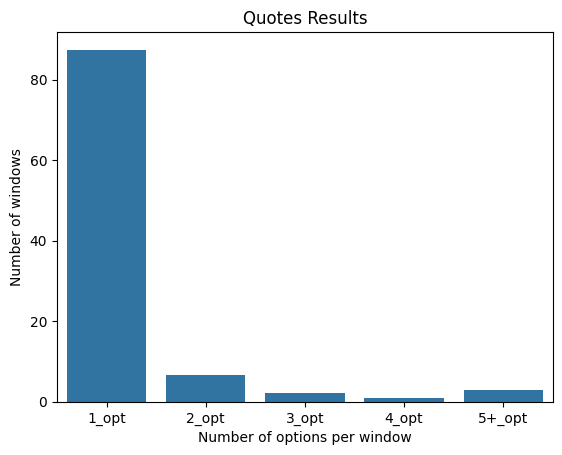

In [29]:
quotes_filter = df_long['text'] == 'quotes'
plot1 = sns.barplot(data=df_long[quotes_filter], x='num_opts', y='windows_percent', errorbar=None)

# Add labels for looks
plot1.set(
    title='Quotes Results',
    xlabel='Number of options per window',
    ylabel='Number of windows'
)